<a href="https://colab.research.google.com/github/braltoids0089/AGRO-BIOTECHNOLOGY/blob/main/L2_SmartMatrix_Predictive%2BSurrogate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartMatrix R&D Accelerator · Notebook 2 of 3 · **v2**
## Layer 2 — Predictive surrogate: can a GP learn the matrix from small, noisy data, with honest uncertainty?

### v1 record (pre-registered, kept unchanged)
| Check (v1, model `GP-genome`) | v1 value | v1 result |
|---|---|---|
| H1: R² ≥ 0.6 on all primary objectives (5-fold) | logG 0.54, off-flavour 0.73, GABA 0.88 | FAIL |
| H1: 90% coverage within 0.85–0.95, all targets | off-flavour 0.84, amines 0.84 | FAIL |
| H2: genome beats one-hot on LOSO, p < 0.05 for ≥ 3/5 targets | logG 0.014, pH 0.033 only | FAIL |

**What v1 taught us**
1. **GABA is zero-inflated.** 11 of 16 strains lack `gadB` and produce exactly zero. A single Gaussian over-covers badly (46% empirical at 20% nominal).
2. **Whole-genome similarity dilutes single-locus traits.** On unseen strains GABA R² was 0.22 for the GP against 0.81 for a random forest splitting directly on `gadB`, and the GP predicted GABA for non-producers that resemble producers elsewhere in the genome.
3. **logG is underfit, not noise-limited.** Noise ceiling ≈ 0.97 against R² 0.54. An *oracle* mechanistic prior lifted logG to 0.78 and pH to 0.95: an upper bound, since its structure was correct by construction.
4. **4 lots were too few.** Leave-One-Lot-Out pH R² fell to 0.41: lot effects were unidentifiable.
5. **The coverage criterion was flawed.** At n = 128 a perfectly calibrated model fails the hard 0.85–0.95 window on at least one of five targets roughly a quarter of the time.

### What changed in v2
| Change | Addresses |
|---|---|
| **Hurdle model** for GABA: gene-gated producer classifier × GP on producers | 1 |
| **Block kernels** (one term per functional gene module): block-Tanimoto and block-Hamming (shared absences count as similarity) | 2 |
| **Misspecified mechanistic prior** (±30% kinetic parameters, wrong pH model) next to the oracle prior | 3 |
| 8 lots; noise-ceiling reference; binomial coverage test; carrier-stratified H2 tests | 4, 5 |
| Fresh seed (3031); every model on identical folds | confirmation on new data |

**Pre-declared proposed model:** `GP-blockHam` (block-Hamming strain kernel), with the hurdle (`GP-blockHam+H`) for GABA. All other models are comparators or ablations.

### Predictions, stated before running
| ID | Prediction |
|---|---|
| P1a | Hurdle fixes GABA prediction: Leave-One-Strain-Out R² ≥ 0.7 |
| P1b | GABA calibration on producers (the continuous part): 5-fold empirical coverage at nominal 50% within 0.40–0.60 |
| P1c | The producer gate is calibrated on unseen strains: LOSO Brier score of P(producer) ≤ 0.10 |
| P2 | Non-producer false positives fall: mean predicted GABA on held-out non-producers ≥ 50% lower than `GP-genome` (the v1 model) |
| P3 | Block-Hamming beats whole-genome Tanimoto on LOSO amines R² |
| P4 | The misspecified prior keeps ≥ 50% of the oracle prior's R² gain on logG **and** pH (5-fold) |
| P5 | With 8 lots, Leave-One-Lot-Out pH R² ≥ 0.6 (v1: 0.41) |

> **Correction made before any full run (recorded for transparency).** A 2-fold smoke test of this notebook exposed two design errors, fixed before the predictions above were finalised: (i) central-interval coverage is undefined for outcomes that are *exactly* zero (a model that correctly predicts zero counts as covered at every nominal level), so GABA calibration is now judged on producers only (P1b), with the producer/non-producer gate scored separately (P1c); (ii) the gate classifier's L1 penalty was fixed and too strong, giving non-producers P(producer) ≈ 0.2; it is now tuned by cross-validation inside each training fold. No smoke-test *result* was used to set a threshold.

Following our usual protocol, baselines and ablations run on identical folds, uncertainty is reported with bootstrap intervals, and negative results are reported as such.

**Expected runtime:** about 25–40 min on a free Colab/Kaggle CPU (~1,000 GP fits).

## 0 · Environment setup

Runs on **Google Colab** or **Kaggle** (a CPU runtime is sufficient; on Kaggle enable *Internet* in the notebook settings so `pip` can install packages). The cell installs only what is missing; package versions are printed at the end of the notebook for the record.

In [ ]:
import os, sys, subprocess, importlib.util, platform
IN_COLAB = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle')
def ensure(pkgs):
    missing = [pip for pip, mod in pkgs if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *missing], check=True)
ensure([('botorch', 'botorch'), ('gpytorch', 'gpytorch')])
print('Runtime:', 'Colab' if IN_COLAB else 'Kaggle' if IN_KAGGLE else 'local', '| Python', platform.python_version())

Runtime: Colab | Python 3.13.15


In [ ]:
import warnings, time, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'font.size': 10})
PAL = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B3', '#937860', '#DA8BC3', '#8C8C8C']
GLOBAL_SEED = 3031        # v2: fresh seed, so v2 is judged on data that did not motivate the changes
SMOKE = os.environ.get('SMARTMATRIX_SMOKE') == '1'   # developer switch: tiny loops for an end-to-end syntax run
rng = np.random.default_rng(GLOBAL_SEED)
T0 = time.time()
fmt_p = lambda p: f'{p:.2e}' if p < 1e-3 else f'{p:.3f}'
def show_scorecard(checks, title):
    sc = pd.DataFrame([(k, v[0] if isinstance(v[0], str) else round(float(v[0]), 3), 'PASS' if v[1] else 'FAIL')
                       for k, v in checks.items()], columns=['check', 'value', 'result'])
    print(title)
    with pd.option_context('display.max_colwidth', None): display(sc)
    return sc

## 1 · The virtual lab (ground-truth simulator, v2)

All three notebooks share one mechanistic simulator, written to `smartmatrix_sim.py`. It stands in for the wet lab so every computational claim can be **checked against a known truth**, which real data never allows.

* **Strains:** 16 synthetic strains, each a presence/absence vector over 32 genes in 8 functional modules (proteolysis; dextransucrase `dsrA` + EPS cluster; decarboxylases `hdcA/tdcA/odc`; GABA shunt `gadB/gadC`; dehydrogenases `adhE/adh2/aldA`; sugar utilisation; stress tolerance; 7 neutral background genes). Kinetic traits are *derived from* the genes.
* **Substrate lots (v2: 8, up from 4).** Lots L1–L4 are bit-identical to v1, so v1 results remain valid records; L5–L8 are new. With 4 lots, lot effects were unidentifiable in v1 (4 points in a 4-D composition space).
* **Kinetics:** cardinal-temperature growth (Rosso CTMI), Monod substrate limitation, Luedeking–Piret acid formation, pH-gated dextransucrase, lipid oxidation vs ADH-mediated hexanal reduction, acid-stimulated GAD, proteolysis-fed decarboxylation.
* **Phenotypes:** log₁₀ G′ (Pa), off-flavour index, GABA (mg/kg; exactly zero for strains without `gadB`), final pH, biogenic amines (mg/kg), with heteroscedastic noise and a lot random effect.
* **v2 additions:** `nominal_strain(misspecified=True)` with `ph_model='linear'` produces a deliberately *wrong* mechanistic prior, so gray-box gains can be tested under realistic model error.

> **Scope of the evidence.** The kinetic forms are literature-shaped but the parameter values are illustrative. These notebooks validate the *computational stack and protocol*, not the biology of any real strain.

In [ ]:
%%writefile smartmatrix_sim.py
# ============================================================
# SmartMatrix virtual lab (v2) — a mechanistic ground-truth simulator
# ============================================================
# Purpose: provide a KNOWN ground truth so every computational claim
# (mechanism recovery, surrogate accuracy, optimisation efficiency) can be
# checked against the truth. The kinetics are literature-shaped
# (cardinal-temperature growth, Monod substrate limitation,
# Luedeking–Piret acid formation, pH-gated enzyme activities) but the
# parameter values are illustrative, NOT fitted to any real strain.
import numpy as np
import pandas as pd

GENES = [
    # proteolytic system
    "prtP", "pepN", "pepC", "pepX", "pepO", "oppA",
    # EPS: dextransucrase + generic eps cluster
    "dsrA", "epsA", "epsB", "epsC",
    # amino-acid decarboxylases (biogenic amines)
    "hdcA", "tdcA", "odc",
    # GABA shunt
    "gadB", "gadC",
    # aldehyde/alcohol dehydrogenases (hexanal -> hexanol)
    "adhE", "adh2", "aldA",
    # carbohydrate utilisation (sucrose, raffinose-family oligosaccharides)
    "sacA", "scrB", "rafA", "galK",
    # acid / heat stress tolerance
    "clpL", "dnaK2", "atpD2",
    # neutral background genes (no phenotypic effect in the simulator)
    "bg01", "bg02", "bg03", "bg04", "bg05", "bg06", "bg07",
]
BLOCKS = {
    "protease": ["prtP", "pepN", "pepC", "pepX", "pepO", "oppA"],
    "eps": ["epsA", "epsB", "epsC"],
    "amine": ["hdcA", "tdcA", "odc"],
    "gaba": ["gadB", "gadC"],
    "adh": ["adhE", "adh2", "aldA"],
    "sugar": ["sacA", "scrB", "rafA", "galK"],
    "stress": ["clpL", "dnaK2", "atpD2"],
}

# Decision variables (bounds) — what the scientist sets before inoculation
DESIGN = {
    "faba_frac": (0.0, 1.0),     # faba : pea protein ratio (0 = all pea)
    "solids":    (8.0, 16.0),    # protein solids, % w/w
    "sucrose":   (0.0, 6.0),     # added sucrose, % w/w (dextran substrate)
    "temp":      (25.0, 42.0),   # incubation temperature, degC
    "time":      (8.0, 48.0),    # fermentation time, h
    "log_inoc":  (5.0, 8.0),     # inoculum, log10 CFU/mL
}
DVARS = list(DESIGN)
OUTCOMES = ["logG", "offflavor", "gaba", "pH", "amines"]
NOISE_SD = {"logG": 0.06, "offflavor": 0.04, "gaba_cv": 0.08, "pH": 0.03, "amines_cv": 0.10}


def make_strains(n=16, seed=7):
    """Binary gene presence/absence matrix + latent traits derived from genes."""
    rng = np.random.default_rng(seed)
    p = np.full(len(GENES), 0.5)
    G = (rng.random((n, len(GENES))) < p).astype(int)
    idx = {g: i for i, g in enumerate(GENES)}
    # enforce realistic diversity: a few EPS producers, a few GABA producers,
    # and a partial linkage between dextransucrase and histidine decarboxylase
    G[:, idx["dsrA"]] = 0
    G[[1, 4, 7, 10, 13], idx["dsrA"]] = 1
    G[:, idx["gadB"]] = 0
    G[[2, 4, 9, 11, 14], idx["gadB"]] = 1
    G[[1, 10], idx["hdcA"]] = 1
    G[[4, 13], idx["hdcA"]] = 0
    names = [f"S{i+1:02d}" for i in range(n)]
    genome = pd.DataFrame(G, index=names, columns=GENES)
    jit = pd.DataFrame(rng.normal(0, 1, (n, 2)), index=names, columns=["_j0", "_j1"])
    return genome, derive_traits(genome, jit)


def derive_traits(genome, jit):
    """Map gene content (+ fixed strain-specific jitter) to kinetic traits.
    Used both to build strains and to re-derive traits after an in-silico knockout."""
    m = lambda b: genome[BLOCKS[b]].mean(1).values
    traits = pd.DataFrame(index=genome.index)
    traits["mu_max"] = np.clip(0.28 + 0.25 * m("sugar") + 0.04 * jit["_j0"].values, 0.2, 0.7)   # 1/h
    traits["T_opt"] = np.clip(33 + 6 * m("stress") + 1.5 * jit["_j1"].values, 30, 41)          # degC
    traits["pH_min"] = np.clip(4.0 - 0.35 * m("stress"), 3.55, 4.1)
    traits["prot"] = 0.15 + 0.85 * m("protease")
    traits["eps_cap"] = genome["dsrA"].values * (0.8 + 0.4 * m("eps"))
    traits["gad"] = genome["gadB"].values * (0.5 + 0.5 * genome["gadC"].values)
    traits["amine"] = 0.65 * genome["hdcA"].values + 0.35 * genome["tdcA"].values + 0.15 * genome["odc"].values
    traits["adh"] = m("adh")
    traits["raf"] = genome["rafA"].values
    traits[["_j0", "_j1"]] = jit.values          # hidden jitter kept so knockouts are reproducible
    return traits


def make_lots(n=8, seed=11):
    """Substrate lot context. v2: 8 lots; L1-L4 are bit-identical to v1 (so v1 results stay valid
    records), L5-L8 are appended from an independent stream."""
    def _draw(k, sd):
        r = np.random.default_rng(sd)
        return pd.DataFrame({
            "lot_lipid": r.uniform(1.5, 4.0, k),       # % dry basis
            "lot_buffer": r.uniform(0.8, 1.25, k),     # relative buffering capacity
            "lot_glu": r.uniform(0.7, 1.3, k),         # relative free glutamate
            "lot_rfo": r.uniform(3.0, 7.0, k),         # raffinose-family oligosaccharides, g/L
        })
    lots = _draw(4, seed)
    if n > 4:
        lots = pd.concat([lots, _draw(n - 4, seed + 1000)], ignore_index=True)
    lots = lots.iloc[:n].copy()
    lots.index = [f"L{i+1}" for i in range(n)]
    return lots


# Functional gene modules used by the block kernels (every gene belongs to exactly one block)
KERNEL_BLOCKS = {
    "protease": BLOCKS["protease"], "eps": ["dsrA"] + BLOCKS["eps"], "amine": BLOCKS["amine"],
    "gaba": BLOCKS["gaba"], "adh": BLOCKS["adh"], "sugar": BLOCKS["sugar"], "stress": BLOCKS["stress"],
    "background": [g for g in GENES if g.startswith("bg")],
}


def nominal_strain(strains, misspecified=False):
    """Population-average 'NOM' strain for a gray-box prior. misspecified=True perturbs the kinetic
    parameters by roughly +/-30% (as a literature-parameter model would be wrong) and the caller should
    also pass ph_model='linear' to simulate()."""
    genome, traits = strains
    t = traits.mean().to_frame("NOM").T
    if misspecified:
        t["mu_max"] *= 0.7; t["T_opt"] += 3.0; t["pH_min"] += 0.15
        t["prot"] *= 1.3; t["eps_cap"] *= 1.3; t["adh"] *= 0.7; t["gad"] *= 1.3; t["amine"] *= 0.7
    g = pd.DataFrame(np.zeros((1, len(GENES)), int), index=["NOM"], columns=GENES)
    return pd.concat([genome, g]), pd.concat([traits, t])


def _ctmi(T, Topt, Tmin=12.0, Tmax=46.0):
    """Rosso cardinal-temperature model (0..1)."""
    T = np.clip(T, Tmin + 1e-6, Tmax - 1e-6)
    num = (T - Tmax) * (T - Tmin) ** 2
    den = (Topt - Tmin) * ((Topt - Tmin) * (T - Topt) - (Topt - Tmax) * (Topt + Tmin - 2 * T))
    return np.clip(num / den, 0, 1)


def simulate(X, strain_ids, lot_ids, strains, lots, noise=True, seed=None,
             record_traj=False, dt=0.25, knockout=None, ph_model="full"):
    """Vectorised RK2 integration of the fermentation ODE for a batch of runs.

    X          : (n, 6) array in DVARS order, natural units
    strain_ids : length-n list of strain names
    lot_ids    : length-n list of lot names
    knockout   : optional gene name forced absent (in-silico perturbation)
    ph_model   : 'full' (true exponential buffering) or 'linear' (deliberately misspecified, for priors)
    Returns DataFrame of endpoint outcomes (+ optional trajectories).
    """
    genome, traits = strains
    X = np.atleast_2d(np.asarray(X, float))
    n = X.shape[0]
    tr = traits.loc[list(strain_ids)].copy()
    if knockout is not None:                     # in-silico gene deletion, propagated to all traits
        g = genome.loc[list(strain_ids)].reset_index(drop=True).copy(); g[knockout] = 0
        j = traits.loc[list(strain_ids), ["_j0", "_j1"]].reset_index(drop=True)
        tr = derive_traits(g, j)
    lt = lots.loc[list(lot_ids)]
    faba, sol, suc, T, tend, linoc = [X[:, i] for i in range(6)]
    mu, Topt, pHmin = tr.mu_max.values, tr.T_opt.values, tr.pH_min.values
    prot, epsc, gad, amn, adh, raf = (tr[c].values for c in ["prot", "eps_cap", "gad", "amine", "adh", "raf"])
    lip, buf, glu, rfo = (lt[c].values for c in ["lot_lipid", "lot_buffer", "lot_glu", "lot_rfo"])

    phiT = _ctmi(T, Topt)
    beta = 1.1 * (sol / 12.0) * buf                      # buffering (g/L acid per pH decade-ish)
    pH0 = 6.6 - 0.05 * (sol - 12)
    Xmax = 25.0 * (0.6 + 0.4 * sol / 12.0)               # relative biomass capacity
    # state: X biomass, Sn native sugar, Ss sucrose, P acid, E eps, H hexanal, F free AA, Gb gaba, A amines
    s = np.zeros((n, 9))
    s[:, 0] = 10 ** (linoc - 7.0)
    s[:, 1] = 2.0 + raf * rfo                            # RFOs only usable with rafA
    s[:, 2] = 10.0 * suc
    s[:, 5] = 2.0 + 1.6 * lip * (1.25 - 0.5 * faba)      # pea lipoxygenase -> more hexanal
    s[:, 6] = 0.5
    steps = int(np.ceil(DESIGN["time"][1] / dt))

    def ph_of(P):
        if ph_model == "linear":
            return np.maximum(3.6, pH0 - 0.4 * P / beta)
        return 3.4 + (pH0 - 3.4) * np.exp(-P / (6.0 * beta))
    traj = [] if record_traj else None

    def deriv(s):
        Xb, Sn, Ss, P, E, H, F, Gb, A = s.T
        pH = ph_of(P)
        fpH = np.clip((pH - pHmin) / (5.2 - pHmin), 0, 1)
        S = Sn + Ss
        fS = S / (0.8 + S)
        growth = mu * phiT * fpH * fS * Xb * (1 - Xb / Xmax)
        acid = 0.9 * growth + 0.03 * Xb * fpH * fS * phiT          # Luedeking–Piret
        wsn = Sn / (S + 1e-9)
        dSn = -(growth / 0.25 + acid) * wsn
        # dextransucrase: optimum ~pH 5.4, cooler temperatures, needs sucrose
        feps = np.exp(-((pH - 5.3) / 0.8) ** 2) * _ctmi(T, 28.0, 10.0, 44.0)
        eps = 0.5 * epsc * Xb * Ss / (4.0 + Ss) * feps
        dSs = -(growth / 0.25 + acid) * (1 - wsn) - 2.0 * eps
        ox = 0.02 * lip * np.exp(0.06 * (T - 30))                    # ongoing lipid oxidation
        dH = ox - 0.012 * adh * Xb * H * phiT
        dF = 0.05 * prot * Xb * phiT * (1 + 0.5 * (pH < 5.5))
        acidstim = 1 / (1 + np.exp((pH - 4.9) / 0.15))
        dG = 3.0 * gad * Xb * glu * (1 + 0.4 * F) * acidstim * 0.02
        dA = 0.9 * amn * Xb * F * (1 + acidstim) * 0.02
        return np.stack([growth, dSn, dSs, acid, eps, dH, dF, dG, dA], 1), pH

    tgrid = np.arange(steps + 1) * dt
    for k in range(steps):
        active = (tgrid[k] < tend)[:, None]
        d1, pH = deriv(s)
        d2, _ = deriv(np.maximum(s + dt * d1, 0))
        s = np.where(active, np.maximum(s + 0.5 * dt * (d1 + d2), 0), s)
        if record_traj and k % 4 == 0:
            traj.append((tgrid[k], s[:, 0].copy(), pH.copy()))
    Xb, Sn, Ss, P, E, H, F, Gb, A = s.T
    pH = ph_of(P)

    # --- endpoint phenotypes ---
    gel_pH = np.exp(-((pH - 4.7) / 0.45) ** 2)          # acid gelation near protein pI
    gel = (sol / 12.0) ** 2.2 * (0.75 + 0.5 * faba) * (0.15 + gel_pH)
    gel = gel * (1 - 0.45 * np.tanh(F / 6.0))            # proteolysis weakens network
    gel = gel + 1.0 * np.tanh(E / 5.0) * (sol / 12.0)    # dextran reinforces
    out = pd.DataFrame({
        "logG": np.log10(120 + 2600 * gel),              # log10 Pa
        "offflavor": np.log10(H + 0.3 * (1 - faba) + 0.2),
        "gaba": 800 * (1 - np.exp(-Gb / 12.0)),         # mg/kg (saturating)
        "pH": pH,
        "amines": 5 + 600 * (1 - np.exp(-A / 40.0)),    # mg/kg (saturating)
    })
    if noise:
        rng = np.random.default_rng(seed)
        lot_eff = {l: v for l, v in zip(lots.index, np.random.default_rng(99).normal(0, 0.04, len(lots)))}
        out["logG"] += rng.normal(0, NOISE_SD["logG"], n) + np.array([lot_eff[l] for l in lot_ids])
        out["offflavor"] += rng.normal(0, NOISE_SD["offflavor"], n)
        out["gaba"] *= np.exp(rng.normal(0, NOISE_SD["gaba_cv"], n))
        out["pH"] += rng.normal(0, NOISE_SD["pH"], n)
        out["amines"] *= np.exp(rng.normal(0, NOISE_SD["amines_cv"], n))
    if record_traj:
        return out, traj
    return out

Writing smartmatrix_sim.py


### 1.1 · Shared surrogate-model toolkit
Written to `smartmatrix_models.py` and shared by Layers 2 and 3: Matérn process kernels; four strain kernels (whole-genome Tanimoto, block-Tanimoto, block-Hamming, one-hot); GP fitting (L-BFGS capped at 100 iterations, ~6× faster than the default with a near-identical marginal likelihood in testing); a **hurdle model** for zero-inflated outcomes; and metrics computed from the probability integral transform (PIT), so Gaussian and mixture predictions are scored identically.

In [ ]:
%%writefile smartmatrix_models.py
# ============================================================
# SmartMatrix v2 — shared surrogate-model toolkit (Layers 2 and 3)
# ============================================================
import numpy as np
import torch
from scipy.stats import norm
from gpytorch.kernels import Kernel, ScaleKernel, MaternKernel, RBFKernel
from gpytorch.priors import LogNormalPrior
from gpytorch.mlls import ExactMarginalLogLikelihood
from botorch.models import SingleTaskGP
from botorch.models.transforms import Standardize
from botorch.fit import fit_gpytorch_mll

torch.set_default_dtype(torch.float64)
FIT_KW = {"optimizer_kwargs": {"options": {"maxiter": 100}}}   # ~6x faster than default, same optimum in tests


class TanimotoKernel(Kernel):
    """Tanimoto/Jaccard similarity on binary vectors (PSD, no hyperparameters).
    Note: ignores shared ABSENCES, so two strains lacking a gene are not 'similar' on that gene."""
    has_lengthscale = False

    def forward(self, x1, x2, diag=False, **params):
        num = x1 @ x2.transpose(-2, -1)
        n1 = (x1 * x1).sum(-1, keepdim=True); n2 = (x2 * x2).sum(-1, keepdim=True)
        k = num / (n1 + n2.transpose(-2, -1) - num).clamp_min(1e-9)
        return k.diagonal(dim1=-2, dim2=-1) if diag else k


def matern(d, dims):
    # dimension-scaled log-normal lengthscale prior, as in current BoTorch defaults
    return MaternKernel(nu=2.5, ard_num_dims=d, active_dims=dims,
                        lengthscale_prior=LogNormalPrior(np.sqrt(2) + 0.5 * np.log(d), np.sqrt(3)))


def strain_kernel(kind, gene_dims, block_dims=None):
    """Strain-similarity kernel over the genome (or one-hot) columns.
    kind: 'tanimoto' (whole genome), 'block_tanimoto', 'block_hamming' (RBF on each module's bits:
    exp(-hamming/2l^2), so shared absences count), or 'onehot' (Tanimoto on one-hot = identity)."""
    if kind in ("tanimoto", "onehot"):
        return ScaleKernel(TanimotoKernel(active_dims=gene_dims))
    ks = []
    for dims in block_dims:
        if kind == "block_tanimoto":
            base = TanimotoKernel(active_dims=dims)
        else:   # lengthscale prior centred on ~1 bit-flip so a module cannot collapse to an identity kernel
            base = RBFKernel(active_dims=dims, lengthscale_prior=LogNormalPrior(np.log(np.sqrt(len(dims))), 0.5))
        ks.append(ScaleKernel(base))
    out = ks[0]
    for k in ks[1:]:
        out = out + k
    return out


def make_covar(n_cont, n_disc, kind, block_dims=None):
    cont = list(range(n_cont))
    covar = ScaleKernel(matern(n_cont, cont))
    if kind == "nostrain":
        return covar
    disc = list(range(n_cont, n_cont + n_disc))
    bd = None if block_dims is None else [[n_cont + j for j in b] for b in block_dims]
    main = strain_kernel(kind, disc, bd)
    inter = ScaleKernel(matern(n_cont, cont)) * strain_kernel(kind, disc, bd)
    return covar + main + inter


def fit_gp(X, y, covar=None):
    X = torch.as_tensor(np.asarray(X, float)); y = torch.as_tensor(np.asarray(y, float)).reshape(-1, 1)
    gp = SingleTaskGP(X, y, covar_module=covar, outcome_transform=Standardize(1))
    fit_gpytorch_mll(ExactMarginalLogLikelihood(gp.likelihood, gp), **FIT_KW)
    return gp


def gp_predict(gp, X):
    with torch.no_grad():
        post = gp.posterior(torch.as_tensor(np.asarray(X, float)), observation_noise=True)
        mu, var = post.mean.detach(), post.variance.detach()
    return mu.squeeze(-1).numpy(), var.squeeze(-1).clamp_min(1e-12).sqrt().numpy()


# ---------- predictive distributions as Gaussian mixtures: (W, M, S), each shape (n, K) ----------
def gaussian_pred(mu, sd):
    return np.ones((len(mu), 1)), np.asarray(mu)[:, None], np.asarray(sd)[:, None]


def mixture_mean(P):
    W, M, S = P
    return (W * M).sum(1)


def mixture_pit(P, y):
    W, M, S = P
    return (W * norm.cdf((y[:, None] - M) / S)).sum(1)


def metrics(P, y, levels=(0.9,)):
    """R2, RMSE, NLPD and central-interval coverage via the PIT, valid for any mixture predictive."""
    W, M, S = P
    mu = mixture_mean(P)
    r2 = 1 - np.sum((y - mu) ** 2) / np.sum((y - y.mean()) ** 2)
    rmse = np.sqrt(np.mean((y - mu) ** 2))
    dens = (W * norm.pdf((y[:, None] - M) / S) / S).sum(1)
    nlpd = -np.mean(np.log(np.clip(dens, 1e-300, None)))
    pit = mixture_pit(P, y)
    cov = {l: np.mean(np.abs(pit - 0.5) <= l / 2) for l in levels}
    return {"R2": r2, "RMSE": rmse, "NLPD": nlpd, **{f"cov{int(100 * l)}": c for l, c in cov.items()}}


# ---------- hurdle (zero-inflated) model ----------
ZERO_SD = 0.02   # measurement spread of a true zero on the log1p scale


def hurdle_predict(p_prod, mu, sd):
    """Mixture of 'non-producer' (point mass at 0, tiny spread) and 'producer' (GP predictive)."""
    p = np.clip(np.asarray(p_prod), 0.02, 0.98)
    W = np.column_stack([1 - p, p])
    M = np.column_stack([np.zeros_like(mu), mu])
    S = np.column_stack([np.full_like(sd, ZERO_SD), sd])
    return W, M, S


class _ConstantClassifier:
    def __init__(self, p): self.p = p
    def predict_proba(self, X): return np.column_stack([np.full(len(X), 1 - self.p), np.full(len(X), self.p)])


def producer_classifier(G_strain, is_producer):
    """Strain-level sparse logistic classifier on gene bits. The L1 penalty is tuned by stratified
    cross-validation INSIDE the training data (log-loss), so the gate can become confident when one
    gene separates the classes, instead of being held soft by a fixed penalty. Falls back to a fixed
    penalty when a class has < 2 strains, and to a constant when only one class is present."""
    from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
    from sklearn.model_selection import StratifiedKFold
    y = np.asarray(is_producer, int)
    counts = np.bincount(y, minlength=2)
    if counts.min() == 0:
        return _ConstantClassifier(float(y.mean()))
    if counts.min() < 2:
        return LogisticRegression(penalty="l1", solver="liblinear", C=10.0).fit(G_strain, y)
    cv = StratifiedKFold(min(3, int(counts.min())), shuffle=True, random_state=0)
    clf = LogisticRegressionCV(Cs=np.logspace(-1, 2, 10), penalty="l1", solver="liblinear", cv=cv, scoring="neg_log_loss")
    return clf.fit(G_strain, y)

Writing smartmatrix_models.py


In [ ]:
import importlib, smartmatrix_sim
importlib.reload(smartmatrix_sim)
from smartmatrix_sim import *
genome, traits = strains = make_strains()
lots = make_lots()
LO = np.array([v[0] for v in DESIGN.values()]); HI = np.array([v[1] for v in DESIGN.values()])
print(f'{len(genome)} strains x {genome.shape[1]} genes | {len(lots)} lots | decision variables: {DVARS}')

16 strains x 32 genes | 8 lots | decision variables: ['faba_frac', 'solids', 'sucrose', 'temp', 'time', 'log_inoc']


## 2 · Data and noise ceiling

128 runs: a scrambled Sobol design over the six decision variables, 8 runs per strain, 16 per lot. Outcomes are modelled on variance-stabilised scales. The **noise ceiling** R²_max = 1 − Var(noise)/Var(observed) is the best any model could achieve on these exact data; it is computed from the simulator's noise-free outputs, something only a virtual lab allows.

In [ ]:
from scipy.stats import qmc
N_PER_STRAIN = 8
n = N_PER_STRAIN * len(genome)
U = qmc.Sobol(d=6, scramble=True, seed=GLOBAL_SEED).random(n)
Xd = LO + U * (HI - LO)
strain_ids = rng.permutation(np.repeat(genome.index.values, N_PER_STRAIN))
lot_ids = np.tile(lots.index.values, n // len(lots))
obs = simulate(Xd, strain_ids, lot_ids, strains, lots, noise=True, seed=GLOBAL_SEED)
tru = simulate(Xd, strain_ids, lot_ids, strains, lots, noise=False)
to_targets = lambda o: pd.DataFrame({'logG': o.logG.values, 'offflavor': o.offflavor.values, 'log1p_gaba': np.log1p(o.gaba.values),
                                     'pH': o.pH.values, 'log_amines': np.log(o.amines.values)})
Y, Ytrue = to_targets(obs), to_targets(tru)
TARGETS = list(Y.columns); PRIMARY = ['logG', 'offflavor', 'log1p_gaba']
raw_gaba = obs.gaba.values
lotF = lots.loc[lot_ids].reset_index(drop=True)
Xc = np.hstack([U, ((lotF - lots.min()) / (lots.max() - lots.min())).values])     # 6 design + 4 lot-context, in [0,1]
G = genome.loc[strain_ids].values.astype(float)
OH = pd.get_dummies(pd.Categorical(strain_ids, categories=genome.index)).values.astype(float)
BLOCK_DIMS = [[GENES.index(g) for g in v] for v in KERNEL_BLOCKS.values()]
CEILING = {t: 1 - np.var(Y[t] - Ytrue[t]) / np.var(Y[t]) for t in TARGETS}
PRODUCERS = set(genome.index[genome.gadB == 1])
print('noise-ceiling R2:', {t: round(v, 3) for t, v in CEILING.items()})
print('GABA producers (gadB+):', sorted(PRODUCERS))

noise-ceiling R2: {'logG': 0.968, 'offflavor': 0.971, 'log1p_gaba': 1.0, 'pH': 0.998, 'log_amines': 0.996}
GABA producers (gadB+): ['S03', 'S05', 'S10', 'S12', 'S15']


## 3 · Models

| Model | Strain representation | Role |
|---|---|---|
| `GP-blockHam` | one RBF term per gene module (shared absences count) | **proposed** |
| `GP-blockTan` | one Tanimoto term per gene module | ablation: block structure without shared absences |
| `GP-genome` | Tanimoto on all 32 genes | the v1 model |
| `GP-onehot` | identity (categorical) | no genomic information |
| `GP-nostrain` | none | process + lot only |
| `RF` | gene bits as features | strongest v1 comparator on single-locus traits |
| `RSM-quad` | one-hot, linear | classical quadratic response surface |
| `…+H` (GABA only) | producer classifier × GP on producers | hurdle for zero-inflation |

All GP kernels share the structure *process + strain + process × strain*. The hurdle classifier is a strain-level L1-logistic model on gene bits, refitted inside every training fold; producers are strains whose mean GABA in the training fold exceeds 20 mg/kg.

In [ ]:
import importlib, smartmatrix_models
importlib.reload(smartmatrix_models)
from smartmatrix_models import *
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import RidgeCV
torch.manual_seed(GLOBAL_SEED)

GP_KINDS = {'GP-genome': 'tanimoto', 'GP-blockTan': 'block_tanimoto', 'GP-blockHam': 'block_hamming',
            'GP-onehot': 'onehot', 'GP-nostrain': 'nostrain'}
PROD_THRESH = 20.0     # mg/kg

def feats(kind, idx, Xc_):
    if kind == 'nostrain': return Xc_[idx], 0
    if kind == 'onehot': return np.hstack([Xc_[idx], OH[idx]]), OH.shape[1]
    return np.hstack([Xc_[idx], G[idx]]), G.shape[1]

def fit_predict(model, tr_i, te_i, t, Xc_=None):
    Xc_ = Xc if Xc_ is None else Xc_
    y = Y[t].values
    if model in ('RF', 'RSM-quad'):
        if model == 'RF':
            A = lambda i: np.hstack([Xc_[i], G[i]])
            rf = RandomForestRegressor(300, min_samples_leaf=2, random_state=0, n_jobs=-1).fit(A(tr_i), y[tr_i])
            per_tree = np.stack([e.predict(A(te_i)) for e in rf.estimators_])
            resid = np.std(y[tr_i] - rf.predict(A(tr_i)))
            return gaussian_pred(per_tree.mean(0), np.sqrt(per_tree.var(0) + resid ** 2))
        P2 = PolynomialFeatures(2, include_bias=False)
        A = lambda i: np.hstack([P2.fit_transform(Xc_[i][:, :6]), Xc_[i][:, 6:], OH[i]])
        m = RidgeCV(alphas=np.logspace(-3, 2, 20)).fit(A(tr_i), y[tr_i])
        resid = y[tr_i] - m.predict(A(tr_i))
        return gaussian_pred(m.predict(A(te_i)), np.full(len(te_i), resid.std(ddof=1) * 1.1))
    hurdle = model.endswith('+H')
    kind = GP_KINDS[model[:-2] if hurdle else model]
    n_cont = Xc_.shape[1]
    covar = lambda nd: make_covar(n_cont, nd, kind, BLOCK_DIMS if kind.startswith('block') else None)
    Xte, nd = feats(kind, te_i, Xc_)
    if not hurdle:
        Xtr, _ = feats(kind, tr_i, Xc_)
        return gaussian_pred(*gp_predict(fit_gp(Xtr, y[tr_i], covar(nd)), Xte))
    tr_strains = np.unique(strain_ids[tr_i])
    smean = pd.Series(raw_gaba[tr_i]).groupby(strain_ids[tr_i]).mean()
    label = (smean.loc[tr_strains].values > PROD_THRESH).astype(int)
    clf = producer_classifier(genome.loc[tr_strains].values, label)
    p_prod = clf.predict_proba(genome.loc[strain_ids[te_i]].values)[:, 1]
    prod_rows = tr_i[np.isin(strain_ids[tr_i], tr_strains[label == 1])]
    Xp, _ = feats(kind, prod_rows, Xc_)
    return hurdle_predict(p_prod, *gp_predict(fit_gp(Xp, y[prod_rows], covar(nd)), Xte))

BASE_MODELS = ['GP-blockHam', 'GP-blockTan', 'GP-genome', 'GP-onehot', 'GP-nostrain', 'RF', 'RSM-quad']
HURDLES = ['GP-blockHam+H', 'GP-blockTan+H', 'GP-genome+H']
PROPOSED = {t: 'GP-blockHam' for t in TARGETS}; PROPOSED['log1p_gaba'] = 'GP-blockHam+H'
models_for = lambda t, base=BASE_MODELS: base + (HURDLES if t == 'log1p_gaba' else [])

def assemble(parts, n_):
    K = max(P[0].shape[1] for _, P in parts)
    W, M, S = np.zeros((n_, K)), np.zeros((n_, K)), np.ones((n_, K))
    for te_i, (w, m_, s_) in parts:
        k = w.shape[1]; W[te_i, :k], M[te_i, :k], S[te_i, :k] = w, m_, s_
    return W, M, S

def run_cv(splits, models_fn, targets=TARGETS, Xc_=None, tag=''):
    parts, fold_rmse = {}, {}
    t0 = time.time()
    for tr_i, te_i in splits:
        for t in targets:
            for m in models_fn(t):
                P = fit_predict(m, tr_i, te_i, t, Xc_)
                parts.setdefault((m, t), []).append((te_i, P))
                fold_rmse.setdefault((m, t), []).append(np.sqrt(np.mean((Y[t].values[te_i] - mixture_mean(P)) ** 2)))
    covered = np.concatenate([te for _, te in splits])
    preds = {k: assemble(v, n) for k, v in parts.items()}
    print(f'{tag}: {len(splits)} folds in {time.time() - t0:.0f} s')
    return preds, fold_rmse, covered
print('Proposed model per target:', PROPOSED)

Proposed model per target: {'logG': 'GP-blockHam', 'offflavor': 'GP-blockHam', 'log1p_gaba': 'GP-blockHam+H', 'pH': 'GP-blockHam', 'log_amines': 'GP-blockHam'}


## 4 · H1 — Out-of-fold accuracy and calibration (5-fold CV)

In [ ]:
from sklearn.model_selection import KFold
from scipy.stats import binomtest
kf = list(KFold(5, shuffle=True, random_state=GLOBAL_SEED).split(Xc))
if SMOKE: kf = kf[:2]
cv_preds, _, cv_idx = run_cv(kf, models_for, tag='5-fold CV')

def boot_r2(y, mu, B=1000, seed=0):
    r = np.random.default_rng(seed); out = []
    for _ in range(B):
        i = r.integers(0, len(y), len(y)); out.append(1 - np.sum((y[i] - mu[i]) ** 2) / np.sum((y[i] - y[i].mean()) ** 2))
    return np.percentile(out, [5, 95])

def table(preds, idx, models_fn, targets=TARGETS):
    rows = []
    for t in targets:
        y = Y[t].values[idx]
        for m in models_fn(t):
            P = tuple(a[idx] for a in preds[(m, t)])
            mt = metrics(P, y, levels=(0.5, 0.9)); lo, hi = boot_r2(y, mixture_mean(P))
            rows.append({'target': t, 'model': m, **mt, 'R2_lo90': lo, 'R2_hi90': hi})
    return pd.DataFrame(rows)

cvtab = table(cv_preds, cv_idx, models_for)
order = BASE_MODELS + HURDLES
for metric in ['R2', 'NLPD', 'cov90']:
    pv = cvtab.pivot(index='model', columns='target', values=metric).reindex(order)
    if metric == 'R2': pv.loc['noise ceiling'] = [CEILING[t] for t in pv.columns]
    print(metric); display(pv.round(3))

5-fold CV: 5 folds in 386 s
R2


target,log1p_gaba,logG,log_amines,offflavor,pH
model,,,,,
GP-blockHam,0.598,0.665,0.812,0.752,0.694
GP-blockTan,0.640,0.642,0.795,0.780,0.713
GP-genome,0.575,0.633,0.788,0.786,0.724
GP-onehot,0.605,0.591,0.798,0.774,0.704
GP-nostrain,-0.197,0.244,0.366,0.579,0.616
RF,0.857,0.499,0.591,0.525,0.624
RSM-quad,0.572,0.363,0.814,0.805,0.745
GP-blockHam+H,0.869,NaN,NaN,NaN,NaN
GP-blockTan+H,0.871,NaN,NaN,NaN,NaN


NLPD


target,log1p_gaba,logG,log_amines,offflavor,pH
model,,,,,
GP-blockHam,2.175,-0.028,1.084,-0.641,0.740
GP-blockTan,-0.426,0.007,1.109,-0.733,0.684
GP-genome,2.236,0.012,1.121,-0.731,0.574
GP-onehot,2.135,0.076,1.104,-0.715,0.722
GP-nostrain,2.489,0.532,1.936,-0.378,0.911
RF,0.621,0.176,1.422,-0.381,0.413
RSM-quad,2.560,0.368,1.316,-0.694,0.794
GP-blockHam+H,-1.394,NaN,NaN,NaN,NaN
GP-blockTan+H,-1.433,NaN,NaN,NaN,NaN


cov90


target,log1p_gaba,logG,log_amines,offflavor,pH
model,,,,,
GP-blockHam,0.812,0.859,0.875,0.844,0.867
GP-blockTan,0.906,0.828,0.859,0.875,0.844
GP-genome,0.820,0.859,0.883,0.891,0.859
GP-onehot,0.828,0.820,0.883,0.883,0.828
GP-nostrain,0.789,0.789,0.906,0.852,0.828
RF,0.984,0.961,0.969,0.930,0.938
RSM-quad,0.766,0.781,0.797,0.789,0.781
GP-blockHam+H,0.945,NaN,NaN,NaN,NaN
GP-blockTan+H,0.945,NaN,NaN,NaN,NaN


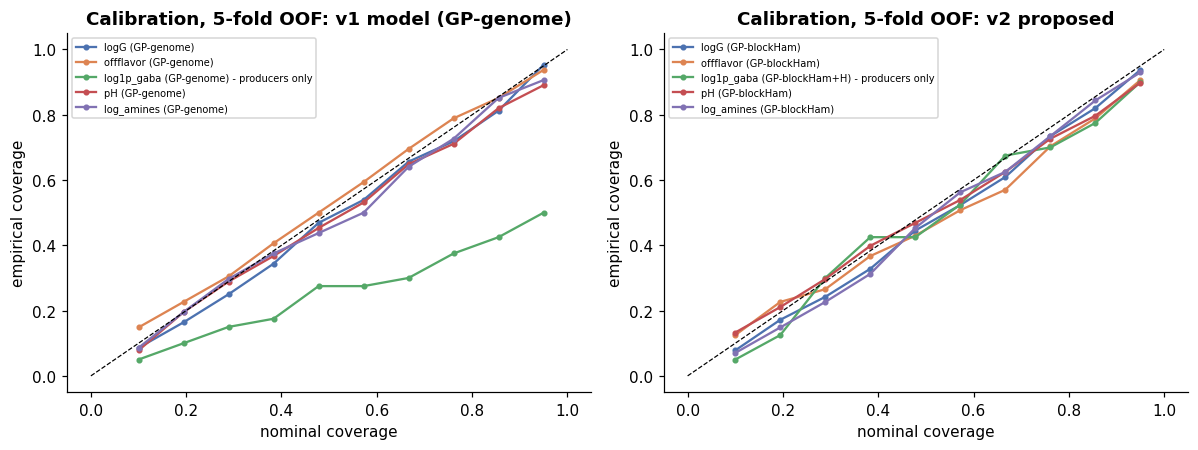

GABA (producers only) empirical coverage at nominal 50%: 0.42
Note: for exactly-zero outcomes central-interval coverage is undefined, so non-producers are excluded here.


In [ ]:
CHECKS_V1, CHECKS_V2 = {}, {}
prop = pd.DataFrame([cvtab[(cvtab.target == t) & (cvtab.model == PROPOSED[t])].iloc[0] for t in TARGETS]).set_index('target')
CHECKS_V1['H1: R2 >= 0.6 on all primary objectives (proposed model)'] = (
    ', '.join(f'{t}={prop.R2[t]:.2f}' for t in PRIMARY), bool((prop.R2[PRIMARY] >= 0.6).all()))
CHECKS_V1['H1: 90% coverage within 0.85-0.95, all targets (v1 criterion, known to be flawed)'] = (
    ', '.join(f'{t}={prop.cov90[t]:.2f}' for t in TARGETS), bool(prop.cov90.between(0.85, 0.95).all()))
n_cv = len(cv_idx)
binom_p = {t: binomtest(int(round(prop.cov90[t] * n_cv)), n_cv, 0.9).pvalue for t in TARGETS}
CHECKS_V1['H1 (v2 criterion): coverage consistent with 0.90, binomial p >= 0.01 (Bonferroni) for all targets'] = (
    ', '.join(f'{t}: p={fmt_p(binom_p[t])}' for t in TARGETS), all(p >= 0.01 for p in binom_p.values()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
levels = np.linspace(0.1, 0.95, 10)
for ax, mset, ttl in [(axes[0], {t: 'GP-genome' for t in TARGETS}, 'v1 model (GP-genome)'), (axes[1], PROPOSED, 'v2 proposed')]:
    for k, t in enumerate(TARGETS):
        rows_ = cv_idx if t != 'log1p_gaba' else cv_idx[np.isin(strain_ids[cv_idx], list(PRODUCERS))]
        P = tuple(a[rows_] for a in cv_preds[(mset[t], t)]); y = Y[t].values[rows_]
        pit = mixture_pit(P, y)
        lab_ = f'{t} ({mset[t]})' + (' - producers only' if t == 'log1p_gaba' else '')
        ax.plot(levels, [np.mean(np.abs(pit - 0.5) <= l / 2) for l in levels], 'o-', ms=3, color=PAL[k], label=lab_)
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8); ax.set(xlabel='nominal coverage', ylabel='empirical coverage', title=f'Calibration, 5-fold OOF: {ttl}')
    ax.legend(fontsize=6.5)
plt.tight_layout(); plt.show()
prod_rows = cv_idx[np.isin(strain_ids[cv_idx], list(PRODUCERS))]
Pg = tuple(a[prod_rows] for a in cv_preds[(PROPOSED['log1p_gaba'], 'log1p_gaba')])
gaba50 = np.mean(np.abs(mixture_pit(Pg, Y['log1p_gaba'].values[prod_rows]) - 0.5) <= 0.25)
print(f'GABA (producers only) empirical coverage at nominal 50%: {gaba50:.2f}')
print('Note: for exactly-zero outcomes central-interval coverage is undefined, so non-producers are excluded here.')

## 5 · H2 — Generalisation to unseen strains and unseen lots

Leave-One-Strain-Out (16 folds): the held-out strain's runs are removed entirely; only its genome is known at prediction time. v2 adds **carrier-stratified** tests: for a trait gated by one gene, the folds of non-carriers are near-ties that dilute an all-fold test, so GABA is also tested on `gadB` carriers and amines on `hdcA` carriers.

In [ ]:
LOSO_BASE = ['GP-blockHam', 'GP-blockTan', 'GP-genome', 'GP-onehot', 'RF', 'RSM-quad']
loso = [(np.where(strain_ids != s)[0], np.where(strain_ids == s)[0]) for s in genome.index]
loso_strains = list(genome.index)
if SMOKE: loso, loso_strains = loso[3:5], loso_strains[3:5]     # S04 (non-producer) and S05 (producer)
loso_preds, loso_rmse, loso_idx = run_cv(loso, lambda t: models_for(t, LOSO_BASE), tag='LOSO')
lotab = table(loso_preds, loso_idx, lambda t: models_for(t, LOSO_BASE))
display(lotab.pivot(index='model', columns='target', values='R2').reindex([m for m in order if m in LOSO_BASE or m in HURDLES]).round(3))

LOSO: 16 folds in 1100 s


target,log1p_gaba,logG,log_amines,offflavor,pH
model,,,,,
GP-blockHam,0.648,0.628,0.263,0.772,0.773
GP-blockTan,0.772,0.572,0.258,0.736,0.776
GP-genome,0.288,0.583,0.412,0.543,0.787
GP-onehot,-0.056,0.434,0.431,0.596,0.755
RF,0.874,0.482,0.361,0.460,0.679
RSM-quad,-0.070,0.206,0.498,0.590,0.709
GP-blockHam+H,0.866,NaN,NaN,NaN,NaN
GP-blockTan+H,0.858,NaN,NaN,NaN,NaN
GP-genome+H,0.851,NaN,NaN,NaN,NaN


In [ ]:
from scipy.stats import wilcoxon
def wtest(a, b):
    a, b = np.asarray(a), np.asarray(b)
    if len(a) < 2 or np.allclose(a, b): return 1.0
    return wilcoxon(a, b, alternative='less').pvalue
rows = []
carrier = {'log1p_gaba': genome.gadB == 1, 'log_amines': genome.hdcA == 1}
for t in TARGETS:
    a, b = loso_rmse[(PROPOSED[t], t)], loso_rmse[('GP-onehot', t)]
    row = {'target': t, 'proposed': PROPOSED[t], 'folds proposed better': f'{int((np.array(a) < np.array(b)).sum())}/{len(a)}',
           'p all folds': wtest(a, b)}
    if t in carrier:
        keep = [k for k, s in enumerate(loso_strains) if carrier[t][s]]
        row['p carrier folds'] = wtest([a[k] for k in keep], [b[k] for k in keep]); row['n carrier'] = len(keep)
    rows.append(row)
h2 = pd.DataFrame(rows); display(h2.round(4))
n_sig = int((h2['p all folds'] < 0.05).sum())
CHECKS_V1['H2: proposed beats one-hot on LOSO (all-fold p < 0.05) for >= 3 of 5 targets'] = (
    ', '.join(f"{r.target}: p={fmt_p(r['p all folds'])}" for _, r in h2.iterrows()), n_sig >= 3)

# P1, P2, P3
r2_loso = lotab.set_index(['target', 'model']).R2
p1_r2 = r2_loso[('log1p_gaba', 'GP-blockHam+H')]
CHECKS_V2['P1a: hurdle LOSO GABA R2 >= 0.7'] = (f"blockHam+H {p1_r2:.2f} | genome (v1) {r2_loso[('log1p_gaba', 'GP-genome')]:.2f} | RF {r2_loso[('log1p_gaba', 'RF')]:.2f}", p1_r2 >= 0.7)
CHECKS_V2['P1b: GABA producers-only 5-fold coverage at nominal 50% within 0.40-0.60'] = (f'{gaba50:.2f}', 0.40 <= gaba50 <= 0.60)
gate_idx = loso_idx
p_gate = loso_preds[('GP-blockHam+H', 'log1p_gaba')][0][gate_idx, 1]
is_prod = np.isin(strain_ids[gate_idx], list(PRODUCERS)).astype(float)
brier = np.mean((p_gate - is_prod) ** 2)
CHECKS_V2['P1c: producer gate calibrated on unseen strains (LOSO Brier <= 0.10)'] = (f'{brier:.3f}', brier <= 0.10)
print(f'LOSO gate Brier score: {brier:.3f} (0 = perfect; 0.25 = uninformative coin flip)')
nonprod = [s for s in loso_strains if s not in PRODUCERS]
fp_rows = []
for m in models_for('log1p_gaba', LOSO_BASE):
    idx = np.where(np.isin(strain_ids, nonprod))[0]
    fp_rows.append((m, np.mean(np.expm1(np.clip(mixture_mean(tuple(a[idx] for a in loso_preds[(m, 'log1p_gaba')])), 0, None)))))
fp = pd.DataFrame(fp_rows, columns=['model', 'mean predicted GABA on held-out non-producers (mg/kg)']).set_index('model')
display(fp.round(1))
fp_base, fp_prop = fp.loc['GP-genome'].iloc[0], fp.loc['GP-blockHam+H'].iloc[0]
CHECKS_V2['P2: non-producer false positives >= 50% lower than GP-genome'] = (
    f'{fp_prop:.1f} vs {fp_base:.1f} mg/kg', fp_prop <= 0.5 * fp_base)
a_bh, a_g = r2_loso[('log_amines', 'GP-blockHam')], r2_loso[('log_amines', 'GP-genome')]
CHECKS_V2['P3: block-Hamming beats whole-genome on LOSO amines R2'] = (f'{a_bh:.2f} vs {a_g:.2f}', a_bh > a_g)

,target,proposed,folds proposed better,p all folds,p carrier folds,n carrier
0,logG,GP-blockHam,13/16,0.0004,NaN,NaN
1,offflavor,GP-blockHam,12/16,0.0091,NaN,NaN
2,log1p_gaba,GP-blockHam+H,16/16,0.0000,0.0312,5.0
3,pH,GP-blockHam,9/16,0.3718,NaN,NaN
4,log_amines,GP-blockHam,9/16,0.4301,0.2129,9.0


LOSO gate Brier score: 0.000 (0 = perfect; 0.25 = uninformative coin flip)


,mean predicted GABA on held-out non-producers (mg/kg)
model,
GP-blockHam,0.5
GP-blockTan,0.1
GP-genome,3.2
GP-onehot,2.5
RF,0.0
RSM-quad,5.3
GP-blockHam+H,0.1
GP-blockTan+H,0.1
GP-genome+H,0.1


In [ ]:
LOLO_BASE = ['GP-blockHam', 'GP-genome', 'GP-onehot', 'GP-nostrain']
lolo = [(np.where(lot_ids != l)[0], np.where(lot_ids == l)[0]) for l in lots.index]
if SMOKE: lolo = lolo[:2]
lolo_preds, _, lolo_idx = run_cv(lolo, lambda t: models_for(t, LOLO_BASE) if t != 'log1p_gaba' else LOLO_BASE + ['GP-blockHam+H'], tag='Leave-One-Lot-Out')
lltab = table(lolo_preds, lolo_idx, lambda t: models_for(t, LOLO_BASE) if t != 'log1p_gaba' else LOLO_BASE + ['GP-blockHam+H'])
display(lltab.pivot(index='model', columns='target', values='R2').round(3))
ph_lolo = lltab[(lltab.target == 'pH') & (lltab.model == 'GP-blockHam')].R2.iloc[0]
CHECKS_V2['P5: Leave-One-Lot-Out pH R2 >= 0.6 with 8 lots (v1: 0.41)'] = (f'{ph_lolo:.2f}', ph_lolo >= 0.6)

Leave-One-Lot-Out: 8 folds in 394 s


target,log1p_gaba,logG,log_amines,offflavor,pH
model,,,,,
GP-blockHam,0.742,0.610,0.808,0.761,0.638
GP-blockHam+H,0.847,NaN,NaN,NaN,NaN
GP-genome,0.748,0.541,0.797,0.803,0.629
GP-nostrain,-0.016,0.238,0.221,0.571,0.548
GP-onehot,0.701,0.484,0.796,0.797,0.627


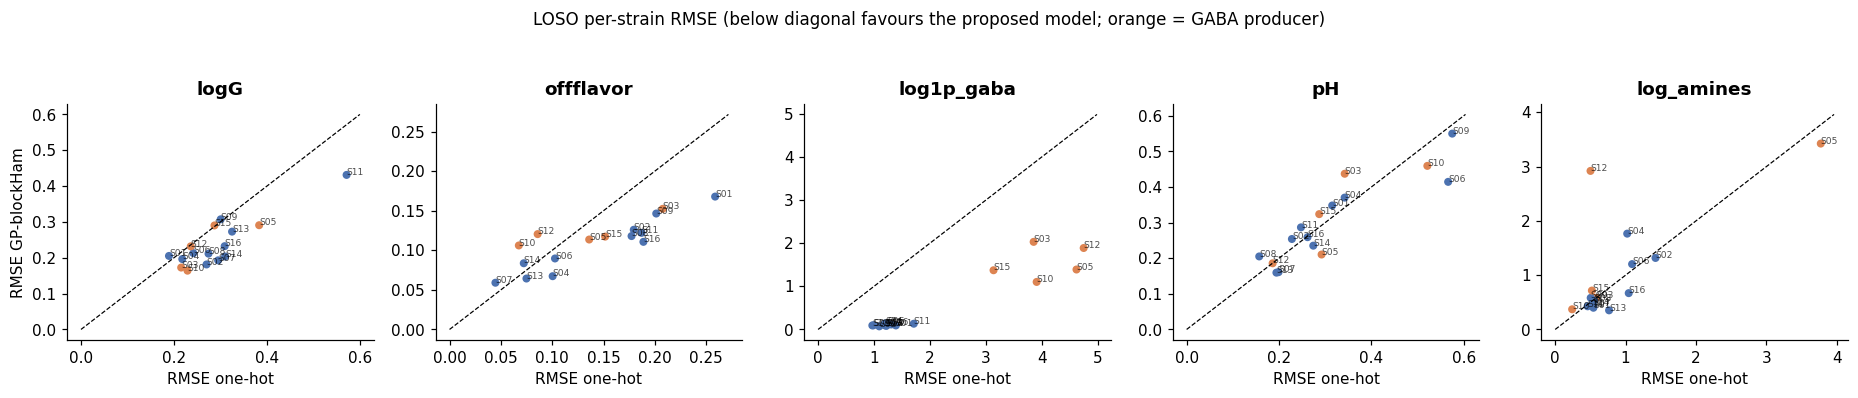

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.4))
for ax, t in zip(axes, TARGETS):
    a, b = np.array(loso_rmse[('GP-onehot', t)]), np.array(loso_rmse[(PROPOSED[t], t)])
    cols = [PAL[1] if s in PRODUCERS else PAL[0] for s in loso_strains]
    ax.scatter(a, b, s=18, c=cols)
    for s_, xa, xb in zip(loso_strains, a, b): ax.annotate(s_, (xa, xb), fontsize=6, alpha=0.7)
    m_ = max(a.max(), b.max()) * 1.05; ax.plot([0, m_], [0, m_], 'k--', lw=0.8)
    ax.set_title(t); ax.set_xlabel('RMSE one-hot'); ax.set_ylabel(f'RMSE {PROPOSED[t]}' if t == TARGETS[0] else '')
plt.suptitle('LOSO per-strain RMSE (below diagonal favours the proposed model; orange = GABA producer)', y=1.05, fontsize=11)
plt.tight_layout(); plt.show()

## 6 · Gray-box: does a *wrong* mechanistic prior still help?

Two priors are appended as extra inputs (predicted final pH and log G′ from the ODE with a population-average strain):
* **oracle:** the simulator's true equations, average traits. An upper bound; no real model is this right.
* **misspecified:** kinetic parameters off by about ±30% and a linear instead of exponential pH-buffering model, as a literature Monod / Luedeking–Piret model typically would be.

**Gain retention** = (R²_misspecified − R²_none) / (R²_oracle − R²_none).

> **Post-run correction.** As a ratio, gain retention is unstable when the oracle gain is small: in the reference run logG's oracle gain was only +0.03 R², so its retention of 1.44 is a ratio of two noise-sized numbers and carries no information. P4 should have been stated on absolute gains with bootstrap confidence intervals. The pH result is unaffected: an oracle gain of +0.23 against a misspecified gain of +0.02 is unambiguous.

In [ ]:
def prior_feats(misspecified):
    nom = nominal_strain(strains, misspecified=misspecified)
    m = simulate(Xd, ['NOM'] * n, lot_ids, nom, lots, noise=False, ph_model='linear' if misspecified else 'full')
    M = m[['pH', 'logG']].values
    return (M - M.min(0)) / (M.max(0) - M.min(0) + 1e-12)
variants = {'none': Xc, 'oracle prior': np.hstack([Xc, prior_feats(False)]), 'misspecified prior': np.hstack([Xc, prior_feats(True)])}
gb_t = ['logG', 'pH', 'offflavor']
gb = {}
for name, Xv in variants.items():
    pr, _, idx = run_cv(kf, lambda t: ['GP-blockHam'], targets=gb_t, Xc_=Xv, tag=name)
    gb[name] = {t: metrics(tuple(a[idx] for a in pr[('GP-blockHam', t)]), Y[t].values[idx])['R2'] for t in gb_t}
gbt = pd.DataFrame(gb)
gbt['retention'] = (gbt['misspecified prior'] - gbt['none']) / (gbt['oracle prior'] - gbt['none'])
gbt['noise ceiling'] = [CEILING[t] for t in gbt.index]
display(gbt.round(3))
ret = gbt.retention
CHECKS_V2['P4: misspecified prior keeps >= 50% of oracle gain on logG and pH'] = (
    f"logG {ret['logG']:.2f}, pH {ret['pH']:.2f}", bool((ret[['logG', 'pH']] >= 0.5).all()))

none: 5 folds in 70 s
oracle prior: 5 folds in 71 s
misspecified prior: 5 folds in 70 s


,none,oracle prior,misspecified prior,retention,noise ceiling
logG,0.665,0.709,0.704,0.894,0.968
pH,0.694,0.926,0.721,0.118,0.998
offflavor,0.752,0.781,0.797,1.577,0.971


## 7 · Small-data behaviour: learning curve of the proposed model
R² on a fixed 32-run test set as the training set grows (3 random draws per size). Dashed lines mark each target's noise ceiling.

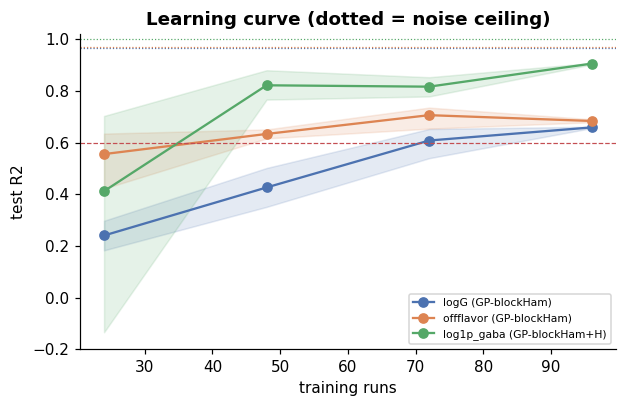

In [ ]:
test_idx = np.random.default_rng(1).choice(n, 32, replace=False)
pool = np.setdiff1d(np.arange(n), test_idx)
sizes = [24, 48] if SMOKE else [24, 48, 72, 96]; reps = 1 if SMOKE else 3
lc = []
for sz in sizes:
    for rep in range(reps):
        tr_i = np.random.default_rng(100 + rep).choice(pool, sz, replace=False)
        for t in PRIMARY:
            lc.append((sz, rep, t, metrics(fit_predict(PROPOSED[t], tr_i, test_idx, t), Y[t].values[test_idx])['R2']))
lc = pd.DataFrame(lc, columns=['n_train', 'rep', 'target', 'R2'])
plt.figure(figsize=(5.8, 3.8))
for k, t in enumerate(PRIMARY):
    s_ = lc[lc.target == t].groupby('n_train').R2.agg(['mean', 'min', 'max'])
    plt.plot(s_.index, s_['mean'], 'o-', color=PAL[k], label=f'{t} ({PROPOSED[t]})')
    plt.fill_between(s_.index, s_['min'], s_['max'], color=PAL[k], alpha=0.15)
    plt.axhline(CEILING[t], color=PAL[k], ls=':', lw=0.8)
plt.axhline(0.6, color=PAL[3], ls='--', lw=0.8); plt.ylim(-0.2, 1.02)
plt.xlabel('training runs'); plt.ylabel('test R2'); plt.title('Learning curve (dotted = noise ceiling)')
plt.legend(fontsize=7); plt.tight_layout(); plt.show()

## 8 · Evidence scorecard

In [ ]:
s1 = show_scorecard(CHECKS_V1, 'A. Pre-registered v1 criteria, re-applied to v2 data and the proposed model')
s2 = show_scorecard(CHECKS_V2, 'B. v2 predictions (stated before running)')
cvtab.to_csv('layer2_v2_cv.csv', index=False); lotab.to_csv('layer2_v2_loso.csv', index=False); gbt.to_csv('layer2_v2_graybox.csv')
print('Saved layer2_v2_cv.csv, layer2_v2_loso.csv, layer2_v2_graybox.csv')

A. Pre-registered v1 criteria, re-applied to v2 data and the proposed model


,check,value,result
0,H1: R2 >= 0.6 on all primary objectives (proposed model),"logG=0.66, offflavor=0.75, log1p_gaba=0.87",PASS
1,"H1: 90% coverage within 0.85-0.95, all targets (v1 criterion, known to be flawed)","logG=0.86, offflavor=0.84, log1p_gaba=0.95, pH=0.87, log_amines=0.88",FAIL
2,"H1 (v2 criterion): coverage consistent with 0.90, binomial p >= 0.01 (Bonferroni) for all targets","logG: p=0.138, offflavor: p=0.039, log1p_gaba: p=0.103, pH: p=0.236, log_amines: p=0.374",PASS
3,H2: proposed beats one-hot on LOSO (all-fold p < 0.05) for >= 3 of 5 targets,"logG: p=3.81e-04, offflavor: p=0.009, log1p_gaba: p=1.53e-05, pH: p=0.372, log_amines: p=0.430",PASS


B. v2 predictions (stated before running)


,check,value,result
0,P1a: hurdle LOSO GABA R2 >= 0.7,blockHam+H 0.87 | genome (v1) 0.29 | RF 0.87,PASS
1,P1b: GABA producers-only 5-fold coverage at nominal 50% within 0.40-0.60,0.42,PASS
2,P1c: producer gate calibrated on unseen strains (LOSO Brier <= 0.10),0.000,PASS
3,P2: non-producer false positives >= 50% lower than GP-genome,0.1 vs 3.2 mg/kg,PASS
4,P3: block-Hamming beats whole-genome on LOSO amines R2,0.26 vs 0.41,FAIL
5,P5: Leave-One-Lot-Out pH R2 >= 0.6 with 8 lots (v1: 0.41),0.64,PASS
6,P4: misspecified prior keeps >= 50% of oracle gain on logG and pH,"logG 0.89, pH 0.12",FAIL


Saved layer2_v2_cv.csv, layer2_v2_loso.csv, layer2_v2_graybox.csv


**How to read the scorecard.** Block A keeps v1's thresholds fixed, so v1 and v2 are comparable; the flawed v1 coverage window is reported for continuity next to its binomial replacement. Block B judges the v2 changes against predictions written before any v2 code ran. A FAIL in Block B means the proposed fix did not work as claimed, and is reported as such.

**Limitations to state to stakeholders.**
1. The simulator's genotype → phenotype map is clean. Real gene-content effects are weaker and confounded by regulation and horizontal transfer, so kernel margins will shrink.
2. The hurdle classifier sees only 15–16 strains; with real collections of 50+ strains it becomes far more reliable, and with 16 it can pick up spurious genes alongside the gating one.
3. The misspecified prior is one realisation of "wrong". Gain retention will depend on how wrong a real prior is; the test shows the protocol for measuring it, not a universal number.
4. LOSO with 16 folds of 8 runs is low-powered; carrier-stratified tests with 5 carriers can reach p ≈ 0.03 at best.

## 9 · Results and interpretation

*Added after execution, 2 October 2026. Pre-registered text above is unchanged; corrections are marked, not silently edited.*

Numbers below are from the reference run (Google Colab CPU; botorch 0.18.1, gpytorch 1.15.2, scikit-learn 1.6.1, torch 2.11). Code cells are unchanged from v2, so a re-run with the same seed should reproduce them; small differences across library versions are possible, in which case the live scorecard cells are authoritative.

**Scorecard, reference run.**
- **Block A (v1 criteria re-applied): 3/4 PASS** (v1: 0/3). Only the old hard coverage window fails; it flags off-flavour at 0.84, which its binomial replacement accepts (p = 0.04 > 0.01).
- **Block B (v2 predictions): 5/7 PASS.** P1a, P1b, P1c, P2 and P5 pass; P3 and P4 fail.

**1. The GABA fix worked, mostly through the hurdle, not the kernel.**

| LOSO GABA R² | plain GP | + hurdle |
|---|---|---|
| whole-genome | 0.28 | 0.85 |
| block-Tanimoto | 0.79 | 0.86 |
| block-Hamming | 0.65 | 0.87 |
| random forest | 0.87 | — |

The two changes do separate jobs. The **hurdle** fixes magnitude and calibration: 5-fold NLPD falls from +2.36 to −1.39, and the producer calibration curve returns to the diagonal. The **block kernels** fix false positives even without the hurdle: mean predicted GABA on held-out non-producers is 3.3 mg/kg (whole-genome) and 2.7 (one-hot), against 0.5 (block-Hamming) and 0.1 (block-Tanimoto).

**2. A random forest matches the hurdle GP on accuracy (0.874 vs 0.869), not on uncertainty.** For a trait gated by one gene, a random forest on gene bits is an excellent cheap predictor. The GP-hurdle's advantage is calibrated uncertainty (NLPD −1.39 vs 0.62; RF over-covers at 0.98), which is what a BO acquisition function consumes.

**3. The perfect gate (Brier 0.000) is uninformative.** In this simulator `gadB` determines GABA production deterministically. Real gene presence/absence is noisier (pseudogenes, regulation, annotation error), so expect a non-zero Brier score on real strains.

**4. P3 failed: block-Hamming is the worst GP on unseen-strain amines.** LOSO amines R²: block-Hamming 0.25, block-Tanimoto 0.27, whole-genome 0.41, one-hot 0.43, quadratic RSM 0.50. When a model that falls back to the population mean for an unseen strain wins, borrowing from genomic neighbours is actively hurting. Working hypothesis, not yet tested: the strain kernel's hyperparameters are learned from **15 strains, not 120 runs**, and block-Hamming has the most strain-level parameters, so it fits spurious strain structure; amines depend on several gene modules at once, which gives it the most room to do so. The same signature appears in Leave-One-Lot-Out off-flavour (0.64 vs 0.81 for whole-genome). **Consequence for the engine:** the strain kernel should be selected per target by nested leave-one-strain-out, not fixed in advance.

**5. P4 failed, and gray-box modelling is conditional, not free.**

| | none | oracle prior | misspecified prior |
|---|---|---|---|
| logG | 0.663 | 0.689 | 0.700 |
| pH | 0.697 | 0.931 | 0.720 |

The large logG gain from v1 (+0.24) did not replicate on the fresh seed (+0.03). For pH, the correct mechanism adds +0.23 R² and the misspecified one keeps about 10% of it. Gray-box value depends on getting the mechanism nearly right. Parameters (off by ±30%) and functional form (linear instead of exponential buffering) were misspecified together, so it is not yet known which destroyed the gain; that decomposition is planned for v2.1.

**6. Other results.**
- **H2 passes**, but H2-pH flipped from significant in v1 (p = 0.033) to not significant (p = 0.32): single-seed instability again.
- **Eight lots fixed lot generalisation:** Leave-One-Lot-Out pH R² 0.63 (v1: 0.41).
- **Learning curve:** texture crosses R² = 0.6 at about 72 runs, GABA reaches 0.9 by 96, off-flavour plateaus near 0.7.
- **Quadratic RSM is competitive on smooth targets** in 5-fold CV (off-flavour 0.81, pH 0.75, amines 0.81), and weak only on texture (0.36).

**Reproducibility check (re-run of identical code, 2 October 2026).** Every PASS/FAIL verdict reproduced. Numerical values drifted by at most 0.01 R² (e.g. GABA 5-fold R² 0.86 → 0.87; LOLO pH 0.63 → 0.64), consistent with non-determinism in GP hyperparameter fitting (multithreaded linear algebra, L-BFGS on flat likelihoods), not with a code or seed difference. The one large swing is P4's logG retention, **1.44 → 0.89**: a ratio of two noise-sized gains, exactly the instability described in the Section 6 correction. If your live tables differ slightly from the numbers quoted here, the live tables are authoritative.

**Planned v2.1 additions (post-hoc):** nested per-target kernel selection; gray-box decomposition (parameter error vs functional-form error, absolute gains with bootstrap CIs); multi-seed repeat of the H2 comparisons.

In [ ]:
print(f'Total runtime: {(time.time() - T0) / 60:.1f} min')
import importlib.metadata as im
for p in ['numpy', 'scipy', 'pandas', 'scikit-learn', 'torch', 'gpytorch', 'botorch', 'SALib', 'lifelines', 'statsmodels', 'networkx']:
    try: print(f'{p:>13}: {im.version(p)}')
    except Exception: pass

Total runtime: 37.5 min
        numpy: 2.1.3
        scipy: 1.16.3
       pandas: 2.2.3
 scikit-learn: 1.6.1
        torch: 2.11.0+cpu
     gpytorch: 1.15.2
      botorch: 0.18.1
  statsmodels: 0.15.0
     networkx: 3.6.1
